In [1]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt

from Vares_simulations import *

from Vares import _terminal_returns, historical_var

Vares.ENABLE_TIMING = False

import pickle

#import the USD data 
with open('prices_usd.pkl', 'rb') as f: 
    prices_usd = pickle.load(f)

with open('original_returns_usd.pkl', 'rb') as f: 
    original_returns_usd = pickle.load(f)

with open('log_returns_usd.pkl', 'rb') as f: 
    log_returns_usd = pickle.load(f)    

original_returns_usd_scaled = original_returns_usd * 100
log_returns_usd_scaled = log_returns_usd * 100

In [4]:
from GARCH_VaR_delete_or_merge import *

import inspect

def show_source(obj):
    try:
        print(inspect.getsource(obj))  # [web:2][web:5]
    except (OSError, TypeError, IOError):
        print("Source not available.")  # [web:2][web:6]


def GJRGARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=1, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    # forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)
    print(parameters)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR



Test for determining differences in GARCH VaR simulations

In [1]:
norm_vars = fit_GARCH_VaR(log_returns_usd, normal_GARCH_simulation) 
_norm_vars = np.multiply(norm_vars, -1)
egarch_vars = fit_GARCH_VaR(log_returns_usd, EGARCH_simulation)
_egarch_vars = np.multiply(egarch_vars, -1)
gjrgarch_vars = fit_GARCH_VaR(log_returns_usd, GJRGARCH_simulation) 
_gjrgarch_vars = np.multiply(gjrgarch_vars, -1)
egarcho1_vars = fit_GARCH_VaR(log_returns_usd, EGARCHo1_simulation) 
_egarcho1_vars = np.multiply(egarcho1_vars, -1)

NameError: name 'fit_GARCH_VaR' is not defined

In [10]:
def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta) * price for log_delta, price in zip(var_array, prices)]

window = 10
cummulative_log_returns = np.convolve(log_returns_usd, np.ones(window), mode='valid')

In [25]:
#test for the significance of the results 
t_stat, p_val = stats.ttest_ind(norm_vars, gjrgarch_vars, equal_var=False, alternative='two-sided')
print(f"Welch t-test GARCH(1,1) and GJR-GARCH(1,1,1): t = {t_stat:.4f}, p = {p_val:.4g}")

t_stat, p_val = stats.ttest_ind(norm_vars, egarch_vars, equal_var=False, alternative='two-sided')
print(f"Welch t-test GARCH(1,1) and EGARCH(1,0,1): t = {t_stat:.4f}, p = {p_val:.4g}")

# egarcho1_vars_nan = np.asarray(egarcho1_vars).ravel()
# egarcho1_vars_nan = egarcho1_vars_nan[~np.isnan(egarcho1_vars_nan)]

# t_stat, p_val = stats.ttest_ind(norm_vars, egarcho1_vars_nan, equal_var=False, alternative='two-sided')
# print(f"Welch t-test GARCH(1,1) and EGARCH(1,1,1): t = {t_stat:.4f}, p = {p_val:.4g}")

# t_stat, p_val = stats.ttest_ind(egarch_vars, egarcho1_vars_nan, equal_var=False, alternative='two-sided')
# print(f"Welch t-test EGARCH(1,0,1) and EGARCH(1,0,1): t = {t_stat:.4f}, p = {p_val:.4g}")


Welch t-test GARCH(1,1) and GJR-GARCH(1,1,1): t = -0.0243, p = 0.9806
Welch t-test GARCH(1,1) and EGARCH(1,0,1): t = -3.0270, p = 0.002489


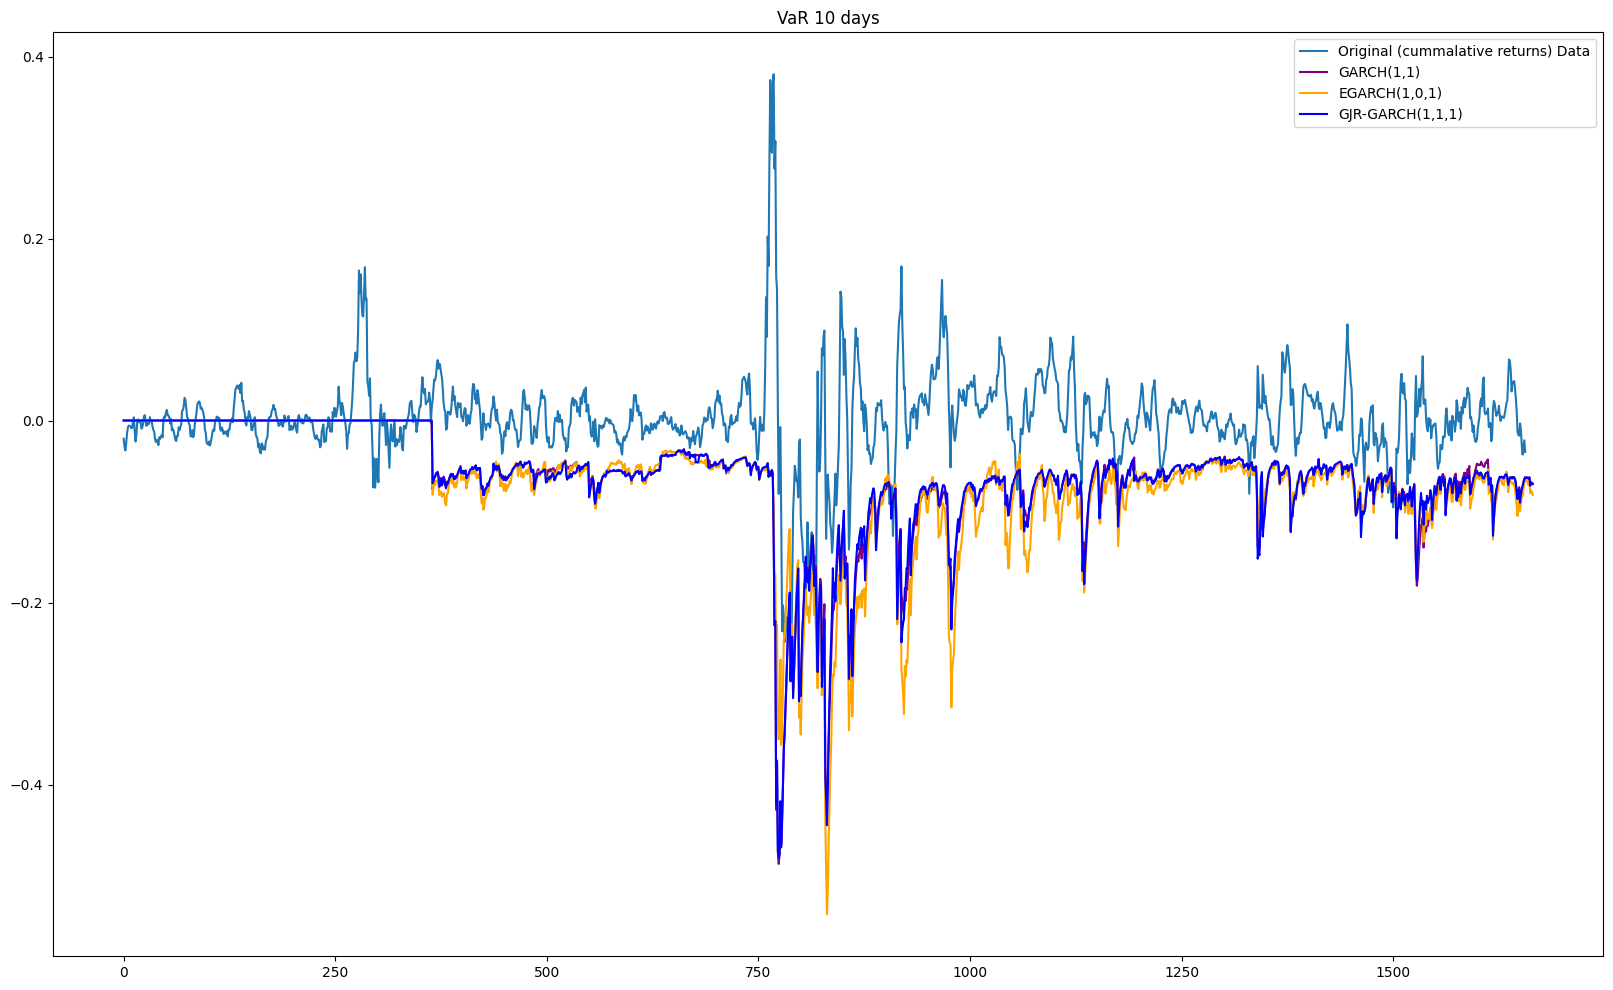

In [24]:
plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original (cummalative returns) Data')
plt.plot(_norm_vars, color='purple', label='GARCH(1,1)')
plt.plot(_egarch_vars, color='orange', label='EGARCH(1,0,1)')
# plt.plot(_egarcho1_vars, color='red', label='EGARCH(1,1,1)')
plt.plot(_gjrgarch_vars, color='blue', label='GJR-GARCH(1,1,1)')
plt.title('VaR 10 days')
plt.legend()
plt.show()

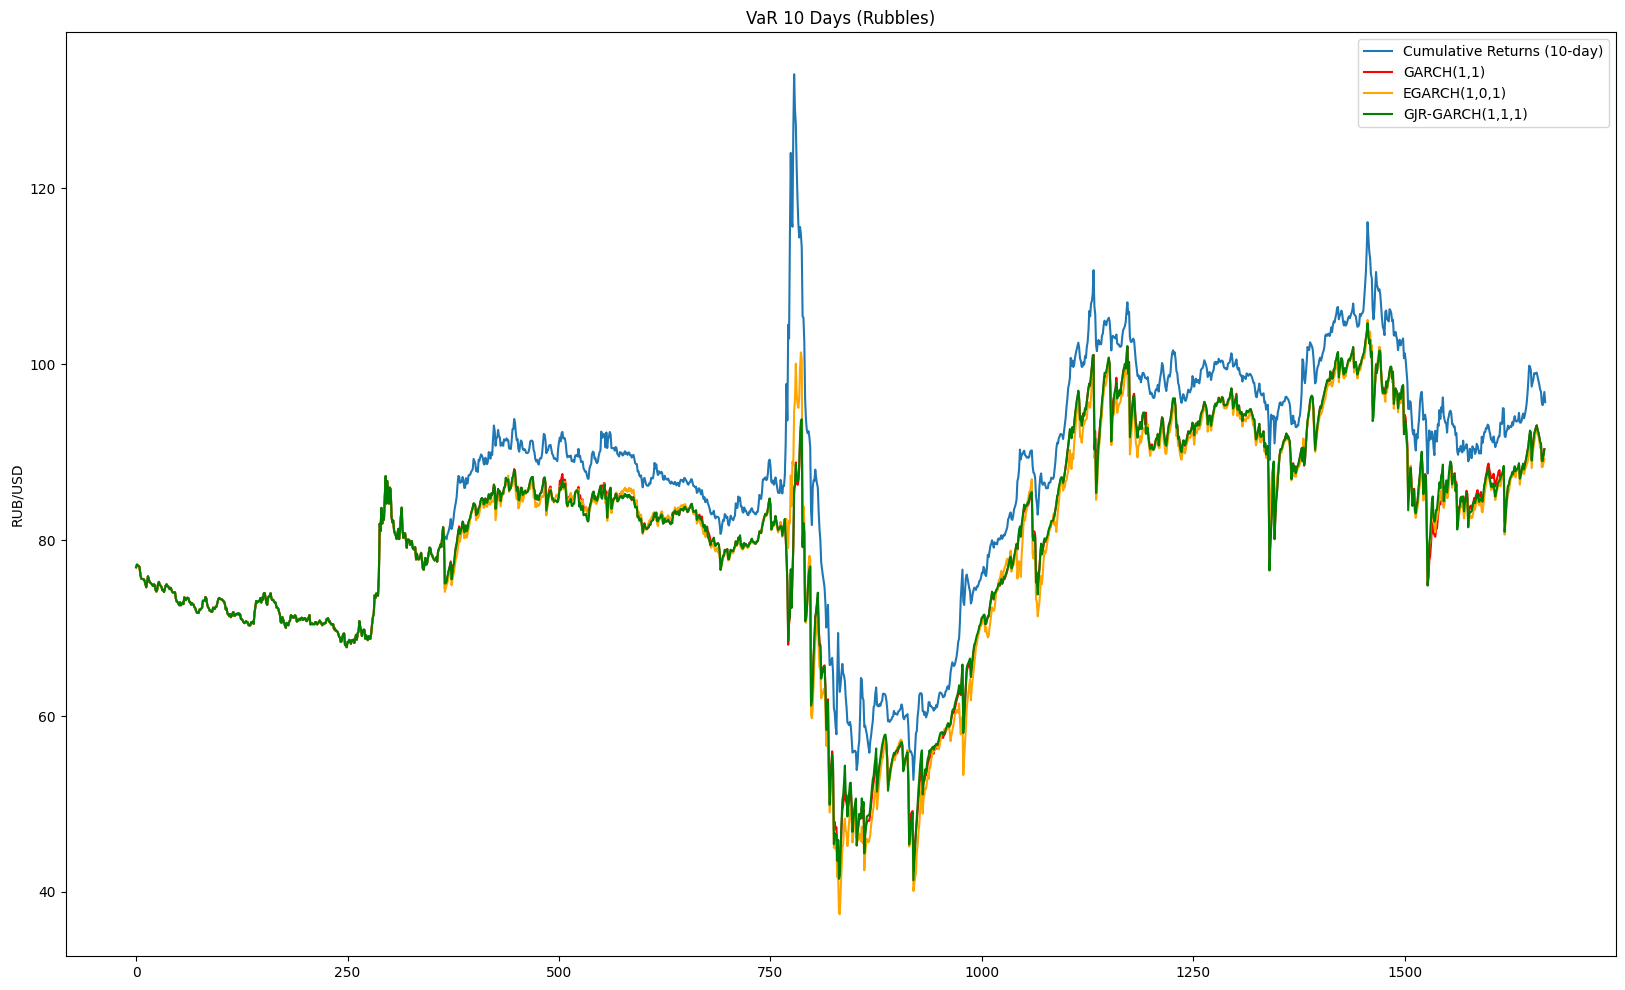

In [27]:
# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(_norm_vars, prices_usd), color='red', label='GARCH(1,1)')
plt.plot(turn_var_into_real_terms(_egarch_vars, prices_usd), color='orange', label='EGARCH(1,0,1)')
# plt.plot(turn_var_into_real_terms(_egarcho1_vars, prices_usd), color='blue', label='EGARCH(1,1,1)')
plt.plot(turn_var_into_real_terms(_gjrgarch_vars, prices_usd), color='green', label='GJR-GARCH(1,1,1)')
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('RUB/USD')
plt.legend()
plt.show()

In [ ]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='red', width=0.5),
    name='GARCH(1, 1)'
))

#Add EGARCH(1, 0, 1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarch_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='EGARCH(1, 0, 1)'
))

# # Add Student's t CI (filled area)
# fig.add_trace(go.Scatter(
#     x=np.arange(len(prices_usd)),
#     y=turn_var_into_real_terms(_egarcho1_vars, prices_usd),
#     mode='lines',
#     line=dict(color='blue', width=0.5),
#     name='EGARCH(1, 1, 1)'
# ))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_gjrgarch_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='GJR-GARCH(1, 1, 1)'
))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=800,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


In [31]:
norm_vars_scaled = fit_GARCH_VaR(log_returns_usd_scaled, normal_GARCH_simulation)
_norm_vars_scaled = np.multiply(norm_vars_scaled, -1)
_norm_vars_scaled_back = _norm_vars_scaled / 100

egarch_vars_scaled = fit_GARCH_VaR(log_returns_usd_scaled, EGARCH_simulation)
_egarch_vars_scaled = np.multiply(egarch_vars_scaled, -1)
_egarch_vars_scaled_back = _egarch_vars_scaled / 100

gjrgarch_vars_scaled = fit_GARCH_VaR(log_returns_usd_scaled, GJRGARCH_simulation)
_gjrgarch_vars_scaled = np.multiply(gjrgarch_vars_scaled, -1)
_gjrgarch_vars_scaled_back = _gjrgarch_vars_scaled / 100

egarcho1_vars_scaled = fit_GARCH_VaR(log_returns_usd_scaled, EGARCHo1_simulation)
_egarcho1_vars_scaled = np.multiply(egarcho1_vars_scaled, -1)
_egarcho1_vars_scaled_back = _egarcho1_vars_scaled / 100

SimParams(volatility=array([0.9484248 , 0.93568567, 0.92343194, 0.91164913, 0.90032299,
       0.88943953, 0.87898499, 0.86894586, 0.85930885, 0.85006096]), mean=np.float64(-0.022222236865581325))
SimParams(volatility=array([0.87686481, 0.86632237, 0.85621281, 0.8465218 , 0.83723531,
       0.82833957, 0.81982109, 0.81166667, 0.80386338, 0.79639861]), mean=np.float64(-0.024027358681351144))
SimParams(volatility=array([0.81437352, 0.8063031 , 0.79858098, 0.79119458, 0.78413163,
       0.77738014, 0.77092842, 0.76476507, 0.75887899, 0.75325938]), mean=np.float64(-0.02345060391681524))
SimParams(volatility=array([0.82428136, 0.81588276, 0.80784139, 0.80014465, 0.79278018,
       0.78573593, 0.77900011, 0.77256124, 0.76640811, 0.7605298 ]), mean=np.float64(-0.02199758630067138))
SimParams(volatility=array([0.77807151, 0.77151863, 0.76526043, 0.7592855 , 0.75358275,
       0.7481414 , 0.74295096, 0.73800125, 0.73328239, 0.72878483]), mean=np.float64(-0.02077931246385636))
SimParams(volatili

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\L

In [34]:
# Normal vs scaled-back
t_stat, p_val = stats.ttest_ind(_norm_vars, _norm_vars_scaled_back, equal_var=False, alternative='two-sided')
print(f"Welch t-test normal vs normal_scaled_back: t = {t_stat:.4f}, p = {p_val:.4g}")

# EGARCH vs scaled-back
t_stat, p_val = stats.ttest_ind(_egarch_vars, _egarch_vars_scaled_back, equal_var=False, alternative='two-sided')
print(f"Welch t-test EGARCH vs EGARCH_scaled_back: t = {t_stat:.4f}, p = {p_val:.4g}")

# GJR-GARCH vs scaled-back
t_stat, p_val = stats.ttest_ind(_gjrgarch_vars, _gjrgarch_vars_scaled_back, equal_var=False, alternative='two-sided')
print(f"Welch t-test GJR-GARCH vs GJR-GARCH_scaled_back: t = {t_stat:.4f}, p = {p_val:.4g}")

# EGARCH(omega=1) vs scaled-back
t_stat, p_val = stats.ttest_ind(_egarcho1_vars, _egarcho1_vars_scaled_back, equal_var=False, alternative='two-sided')
print(f"Welch t-test EGARCHo1 vs EGARCHo1_scaled_back: t = {t_stat:.4f}, p = {p_val:.4g}")


Welch t-test normal vs normal_scaled_back: t = 0.5052, p = 0.6135
Welch t-test EGARCH vs EGARCH_scaled_back: t = -0.0011, p = 0.9991
Welch t-test GJR-GARCH vs GJR-GARCH_scaled_back: t = -1.0058, p = 0.3146
Welch t-test EGARCHo1 vs EGARCHo1_scaled_back: t = nan, p = nan


GJR and regular GARCH

In [36]:
# Welch t-test (means, unequal variances)
t_welch = stats.ttest_ind(_norm_vars, _gjrgarch_vars, equal_var=False, alternative='two-sided')
print(f"Welch t-test: t={t_welch.statistic:.4f}, p={t_welch.pvalue:.4g}")

# Mann–Whitney U (distribution-free difference in central tendency)
mu = stats.mannwhitneyu(_norm_vars, _gjrgarch_vars, alternative='two-sided')
print(f"Mann-Whitney U: U={mu.statistic:.0f}, p={mu.pvalue:.4g}")

# Kolmogorov–Smirnov two-sample (full-distribution difference)
ks = stats.ks_2samp(_norm_vars, _gjrgarch_vars, alternative='two-sided', method='asymp')
print(f"KS two-sample: D={ks.statistic:.4f}, p={ks.pvalue:.4g}")

# Levene (median-centered) for equal variances
lev = stats.levene(_norm_vars, _gjrgarch_vars, center='median')
print(f"Levene (median): W={lev.statistic:.4f}, p={lev.pvalue:.4g}")

# Anderson–Darling k-sample (tail-sensitive distributional test)
ad = stats.anderson_ksamp([_norm_vars, _gjrgarch_vars])
print(f"Anderson-Darling k-sample: A2={ad.statistic:.4f}, p≈{ad.significance_level:.4g}")

# Cliff’s delta (effect size; robust to non-normality)
A, B = _norm_vars, _gjrgarch_vars
cliffs_delta = (np.mean(A[:,None] > B[None,:]) - np.mean(A[:,None] < B[None,:]))
print(f"Cliff's delta: d={cliffs_delta:.4f}")



Welch t-test: t=0.0243, p=0.9806
Mann-Whitney U: U=1398894, p=0.6874
KS two-sample: D=0.0300, p=0.4326
Levene (median): W=0.0299, p=0.8628
Anderson-Darling k-sample: A2=-0.7956, p≈0.25
Cliff's delta: d=0.0080


C:\Users\alexa\AppData\Local\Temp\ipykernel_59480\738604863.py:18: UserWarning:

p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)



EGARCH(1, 1, 1) does not fit properly => what's wrong? \ 

In [44]:
def EGARCHo1_simulation_test(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)
    
    return parameters

In [66]:
def EGARCHo1_simulation_tweaked(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='normal')
    results = model.fit(disp='off', options={'maxiter': 4000, 'eps': 1e-8})
    forecast = results.forecast(horizon=horizon, method='simulation')
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [67]:
egarch01_vars_scaled = fit_GARCH_VaR(log_returns_usd_scaled, EGARCHo1_simulation_tweaked)


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\volatility.py:2792: RuntimeWarning:

overflow encountered in exp

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\mean.py:1000: RuntimeWarning:

invalid value encountered in dot

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\mean.py:1020: RuntimeWarning:

invalid value encountered in dot

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\volatility.py:2792: RuntimeWarning:

overflow encountered in exp

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\mean.py:1000: RuntimeWarning:

invalid value encountered in dot

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\mean.py:1020: RuntimeWarning:

invalid value encountered in dot



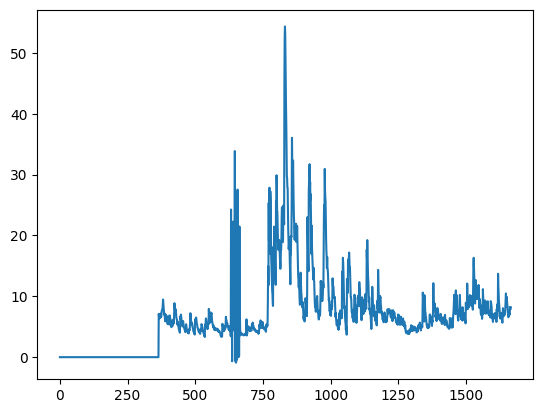

In [ ]:
plt.plot(egarch01_vars_scaled)

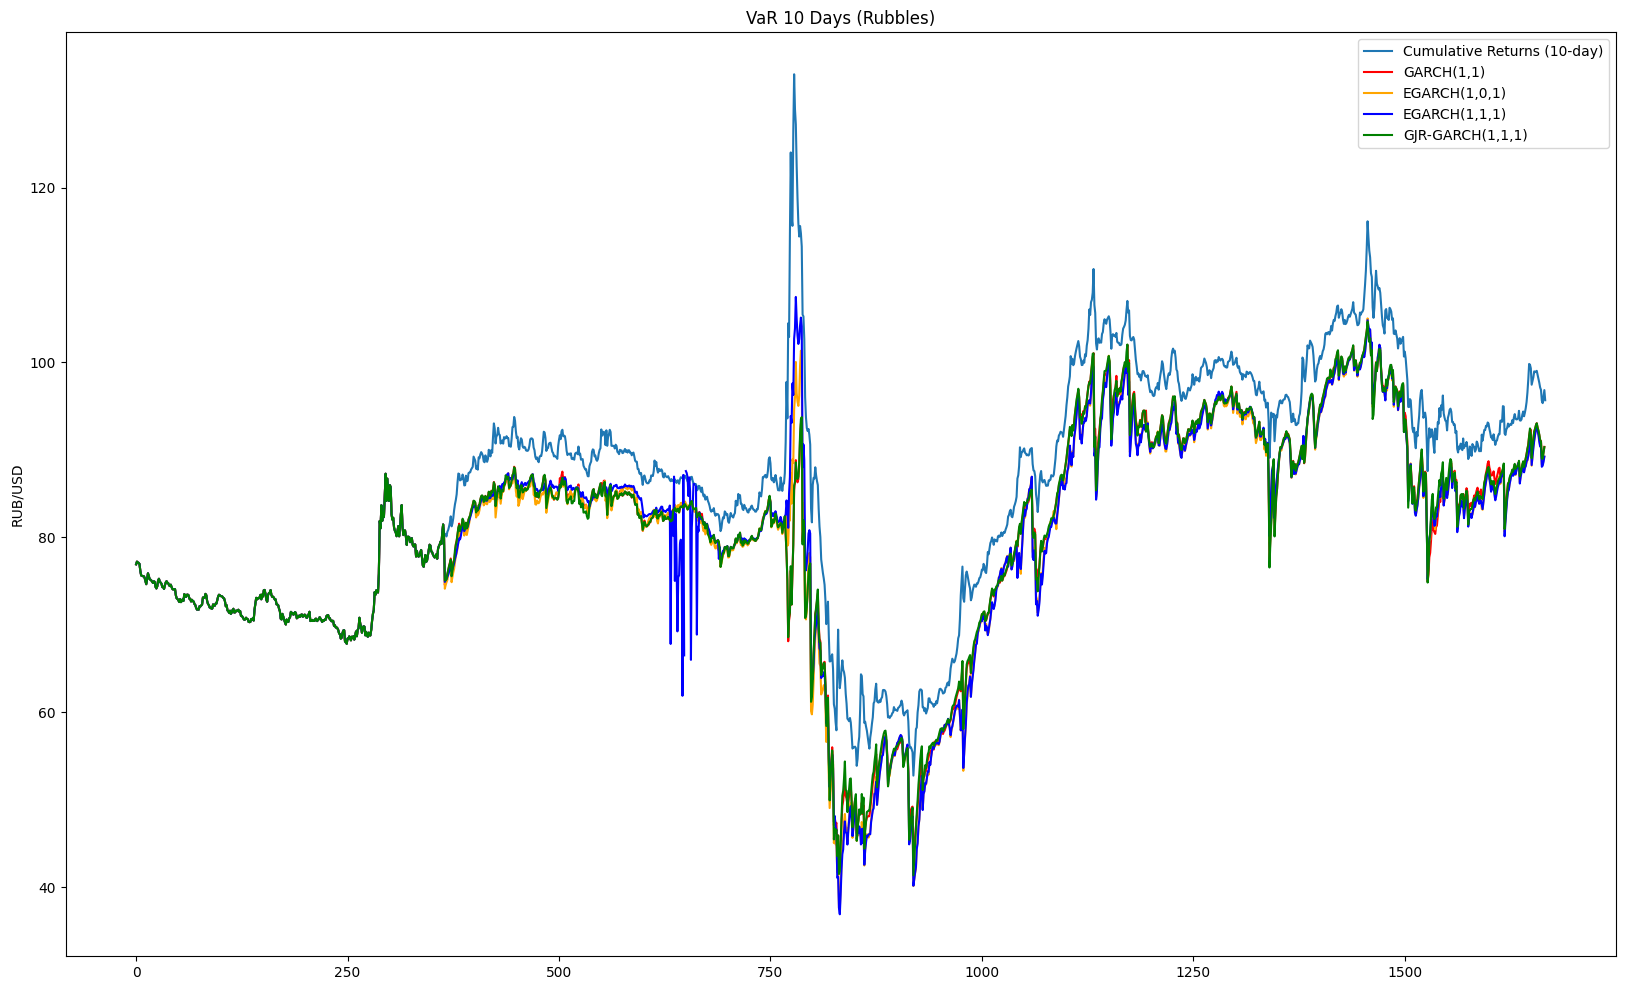

In [70]:
egarch01_vars_scaled_back = np.multiply(egarch01_vars_scaled, 0.01)
_egarch01_vars_scaled_back = np.multiply(egarch01_vars_scaled_back, -1)

# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(_norm_vars, prices_usd), color='red', label='GARCH(1,1)')
plt.plot(turn_var_into_real_terms(_egarch_vars, prices_usd), color='orange', label='EGARCH(1,0,1)')
plt.plot(turn_var_into_real_terms(_egarch01_vars_scaled_back, prices_usd), color='blue', label='EGARCH(1,1,1)')
plt.plot(turn_var_into_real_terms(_gjrgarch_vars, prices_usd), color='green', label='GJR-GARCH(1,1,1)')
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('RUB/USD')
plt.legend()
plt.show()

In [ ]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='red', width=0.5),
    name='GARCH(1, 1)'
))

#Add EGARCH(1, 0, 1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarch_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='EGARCH(1, 0, 1)'
))

# Add Student's t CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarch01_vars_scaled_back, prices_usd),
    mode='lines',
    line=dict(color='blue', width=0.5),
    name='EGARCH(1, 1, 1)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_gjrgarch_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='GJR-GARCH(1, 1, 1)'
))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=800,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


In [71]:
_egarch01_vars_scaled_back_slice = _egarch01_vars_scaled_back[700:]
_egarch_vars_slice =  _egarch_vars[700:]

# Welch t-test (means, unequal variances)
t_welch = stats.ttest_ind(_egarch01_vars_scaled_back_slice, _egarch_vars_slice, equal_var=False, alternative='two-sided')
print(f"Welch t-test: t={t_welch.statistic:.4f}, p={t_welch.pvalue:.4g}")

# Mann–Whitney U (distribution-free difference in central tendency)
mu = stats.mannwhitneyu(_egarch01_vars_scaled_back_slice, _egarch_vars_slice, alternative='two-sided')
print(f"Mann-Whitney U: U={mu.statistic:.0f}, p={mu.pvalue:.4g}")

# Kolmogorov–Smirnov two-sample (full-distribution difference)
ks = stats.ks_2samp(_egarch01_vars_scaled_back_slice, _egarch_vars_slice, alternative='two-sided', method='asymp')
print(f"KS two-sample: D={ks.statistic:.4f}, p={ks.pvalue:.4g}")

# Levene (median-centered) for equal variances
lev = stats.levene(_egarch01_vars_scaled_back_slice, _egarch_vars_slice, center='median')
print(f"Levene (median): W={lev.statistic:.4f}, p={lev.pvalue:.4g}")

# Anderson–Darling k-sample (tail-sensitive distributional test)
ad = stats.anderson_ksamp([_egarch01_vars_scaled_back_slice, _egarch_vars_slice])
print(f"Anderson-Darling k-sample: A2={ad.statistic:.4f}, p≈{ad.significance_level:.4g}")

# Cliff’s delta (effect size; robust to non-normality)
A, B = _egarch01_vars_scaled_back_slice, _egarch_vars_slice
cliffs_delta = (np.mean(A[:,None] > B[None,:]) - np.mean(A[:,None] < B[None,:]))
print(f"Cliff's delta: d={cliffs_delta:.4f}")



Welch t-test: t=0.9269, p=0.3541
Mann-Whitney U: U=472792, p=0.6123
KS two-sample: D=0.0435, p=0.3117
Levene (median): W=0.5675, p=0.4514
Anderson-Darling k-sample: A2=1.0179, p≈0.1243
Cliff's delta: d=0.0133


In [73]:
student_vars = fit_GARCH_VaR(log_returns_usd, student_GARCH_simulation) 

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for line

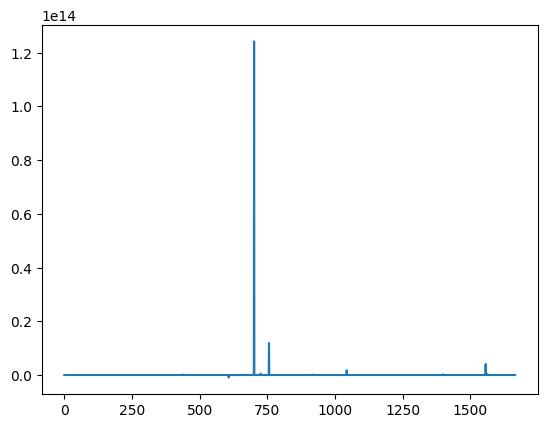

In [74]:
plt.plot(student_vars)